# Hyperparameter and Stability Deep Dive

This notebook is the focused technical appendix for assignment requirements on sensitivity and stability.

It covers:
- seed stability,
- per-algorithm hyperparameter effects,
- parameter-importance ranking,
- practical tuning guidance.

In [1]:
from ast import literal_eval

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from analysis_helpers import (
    ALGORITHM_ORDER,
    ALGORITHM_PALETTE,
    HEATMAP_CMAP,
    save_figure,
    setup_theme,
)
from mlflow.tracking import MlflowClient
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

setup_theme()

In [2]:
PHASE4_SUMMARY_PATH = "../outputs/phase4_summary.csv"
TRACKING_URI = "sqlite:///../mlruns.db"
EXPERIMENT_NAME = "anomaly_detection/phase4"

summary = pd.read_csv(PHASE4_SUMMARY_PATH)
summary = summary[summary["pr_auc"].notna()].copy()
summary["seed"] = pd.to_numeric(summary["seed"], errors="coerce")
summary.head()

,run_name,dataset,algorithm,variant,seed,pr_auc,roc_auc,mcc,f1,distance_concentration_ratio,n_features,pca_variance,recall_type_g,recall_type_l
0,phase4__thyroid__IForest__seed-42__task-003314...,thyroid,IForest,bootstrap-iforest-stable,42,0.669421,0.983536,0.650914,0.659574,45.091528,6.0,NaN,NaN,NaN
1,phase4__pima__OCSVM__seed-42__task-003313__cfg...,pima,OCSVM,lhs-ocsvm-pima,42,0.492475,0.655724,0.246981,0.510242,2.615846,8.0,NaN,NaN,NaN
2,phase4__ionosphere__OCSVM__seed-42__task-00331...,ionosphere,OCSVM,lhs-ocsvm-ionosphere,42,0.902870,0.906279,0.721928,0.822134,2.314527,32.0,NaN,NaN,NaN
3,phase4__breastw__OCSVM__seed-42__task-003311__...,breastw,OCSVM,lhs-ocsvm-breastw,42,0.933811,0.978872,0.868187,0.914405,3.638783,9.0,NaN,NaN,NaN
4,phase4__pima__OCSVM__seed-42__task-003310__cfg...,pima,OCSVM,sobol-ocsvm-pima,42,0.492005,0.655522,0.235528,0.502793,2.615846,8.0,NaN,NaN,NaN


In [3]:
def coerce_param(value: str):
    lowered = str(value).lower()
    if lowered == "true":
        return True
    if lowered == "false":
        return False
    if lowered == "none":
        return None
    try:
        if (
            isinstance(value, str)
            and value.startswith("0")
            and value != "0"
            and not value.startswith("0.")
        ):
            raise ValueError
        return int(value)
    except (TypeError, ValueError):
        pass
    try:
        return float(value)
    except (TypeError, ValueError):
        pass
    try:
        return literal_eval(value)
    except (TypeError, ValueError, SyntaxError):
        return value


client = MlflowClient(tracking_uri=TRACKING_URI)
experiment = client.get_experiment_by_name(EXPERIMENT_NAME)
runs = []
if experiment is not None:
    runs = client.search_runs(
        experiment_ids=[experiment.experiment_id],
        filter_string="attributes.status = 'FINISHED'",
        max_results=50000,
    )

rows = []
for run in runs:
    tags = run.data.tags
    metrics = run.data.metrics
    run_name = tags.get("run_name", run.info.run_name)
    rows.append(
        {
            "run_name": run_name,
            "dataset": tags.get("dataset"),
            "algorithm": tags.get("algorithm"),
            "variant": tags.get("variant"),
            "seed": pd.to_numeric(tags.get("seed"), errors="coerce"),
            "pr_auc": metrics.get("pr_auc"),
            "roc_auc": metrics.get("roc_auc"),
            "mcc": metrics.get("mcc"),
            "params": {k: coerce_param(v) for k, v in run.data.params.items()},
        }
    )

run_df = pd.DataFrame(rows)
run_df = run_df[
    run_df["dataset"].notna() & run_df["algorithm"].notna() & run_df["pr_auc"].notna()
].copy()
run_df.head()

,run_name,dataset,algorithm,variant,seed,pr_auc,roc_auc,mcc,params
1,phase4__thyroid__IForest__seed-42__task-003314...,thyroid,IForest,bootstrap-iforest-stable,42.0,0.669421,0.983536,0.650914,"{'bootstrap_dataset_id': 'thyroid', 'study': '..."
2,phase4__pima__OCSVM__seed-42__task-003313__cfg...,pima,OCSVM,lhs-ocsvm-pima,42.0,0.492475,0.655724,0.246981,"{'lhs_n_samples': 80, 'lhs_seed': 42, 'study':..."
3,phase4__ionosphere__OCSVM__seed-42__task-00331...,ionosphere,OCSVM,lhs-ocsvm-ionosphere,42.0,0.902870,0.906279,0.721928,"{'lhs_n_samples': 80, 'lhs_seed': 42, 'study':..."
4,phase4__breastw__OCSVM__seed-42__task-003311__...,breastw,OCSVM,lhs-ocsvm-breastw,42.0,0.933811,0.978872,0.868187,"{'lhs_n_samples': 80, 'lhs_seed': 42, 'study':..."
5,phase4__pima__OCSVM__seed-42__task-003310__cfg...,pima,OCSVM,sobol-ocsvm-pima,42.0,0.492005,0.655522,0.235528,"{'saltelli_n': 28, 'study': 'sobol_ocsvm'}"


## 1) Seed Stability

I first measure how much PR-AUC moves across seeds for the same dataset and algorithm.

,algorithm,pr_auc_std,pr_auc_range
0,DBSCAN,0.000000,0.00000
1,ECOD,0.000000,0.00000
2,HBOS,0.000000,0.00000
4,LOF,0.000000,0.00000
5,OCSVM,0.000000,0.00000
3,IForest,0.009764,0.02634


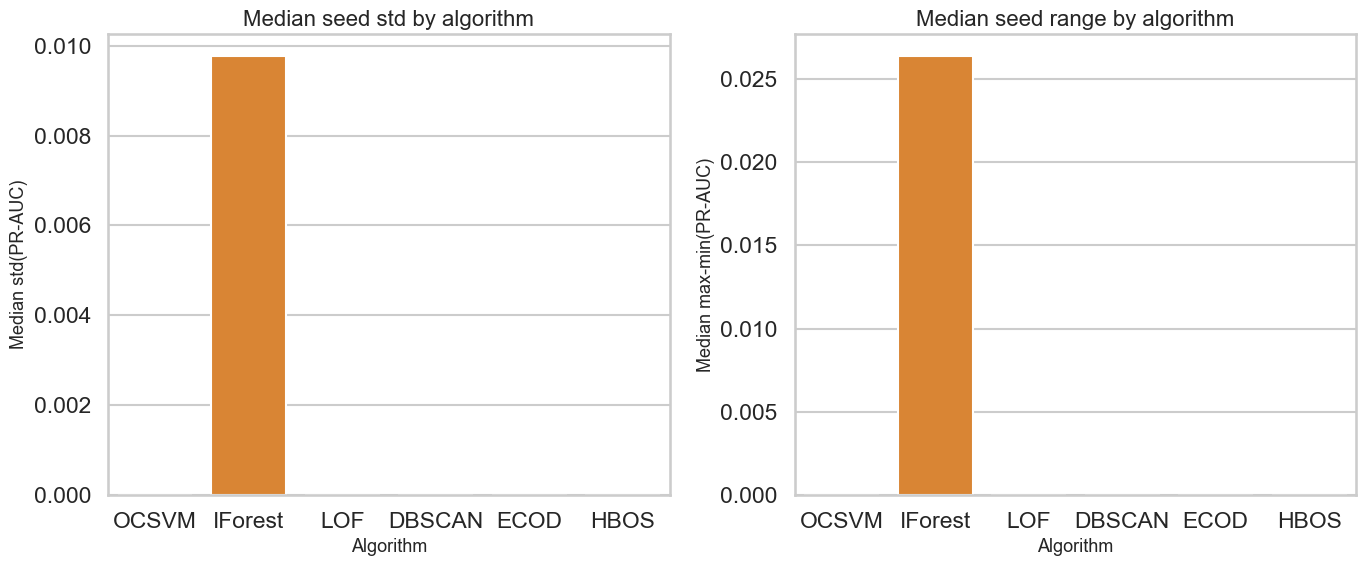

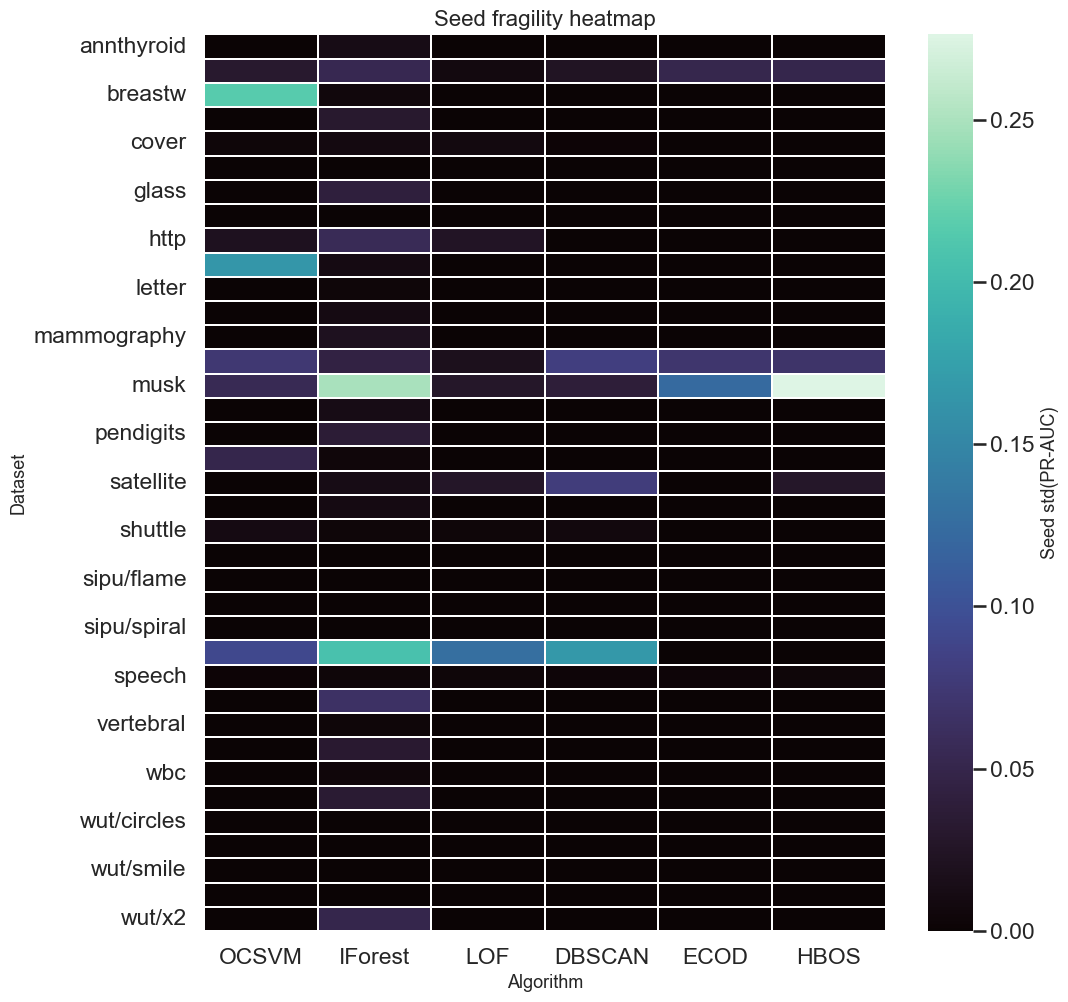

In [4]:
seed_stats = (
    run_df.groupby(["dataset", "algorithm"], as_index=False)["pr_auc"]
    .agg(["mean", "std", "min", "max", "count"])
    .reset_index()
    .rename(
        columns={
            "mean": "pr_auc_mean",
            "std": "pr_auc_std",
            "min": "pr_auc_min",
            "max": "pr_auc_max",
        }
    )
)
seed_stats["pr_auc_range"] = seed_stats["pr_auc_max"] - seed_stats["pr_auc_min"]
seed_stats = seed_stats.fillna({"pr_auc_std": 0.0})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
alg_stab = seed_stats.groupby("algorithm", as_index=False)[["pr_auc_std", "pr_auc_range"]].median()

sns.barplot(
    data=alg_stab,
    x="algorithm",
    y="pr_auc_std",
    hue="algorithm",
    order=ALGORITHM_ORDER,
    hue_order=ALGORITHM_ORDER,
    palette=ALGORITHM_PALETTE,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Median seed std by algorithm")
axes[0].set_xlabel("Algorithm")
axes[0].set_ylabel("Median std(PR-AUC)")

sns.barplot(
    data=alg_stab,
    x="algorithm",
    y="pr_auc_range",
    hue="algorithm",
    order=ALGORITHM_ORDER,
    hue_order=ALGORITHM_ORDER,
    palette=ALGORITHM_PALETTE,
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Median seed range by algorithm")
axes[1].set_xlabel("Algorithm")
axes[1].set_ylabel("Median max-min(PR-AUC)")

plt.tight_layout()
# annotate_figure(
#     fig, "Seed metrics computed across repeated seeds within each dataset+algorithm run group."
# )
save_figure("deepdive_seed_stability_algorithm.png")

pivot = seed_stats.pivot(index="dataset", columns="algorithm", values="pr_auc_std").reindex(
    columns=ALGORITHM_ORDER
)
fig, ax = plt.subplots(figsize=(11, max(8, len(pivot) * 0.28)))
sns.heatmap(pivot, cmap=HEATMAP_CMAP, linewidths=0.2, cbar_kws={"label": "Seed std(PR-AUC)"}, ax=ax)
ax.set_title("Seed fragility heatmap")
ax.set_xlabel("Algorithm")
ax.set_ylabel("Dataset")
plt.tight_layout()
# annotate_figure(fig, "Heatmap values are std(PR-AUC) across seeds per dataset+algorithm.")
save_figure("deepdive_seed_fragility_heatmap.png")

alg_stab.sort_values("pr_auc_std")

## 2) Hyperparameter Effects by Algorithm

This section inspects each method on its own parameter space instead of mixing all models together.

In [5]:
ALGO_PARAM_CANDIDATES = {
    "OCSVM": ["kernel", "nu", "gamma", "degree", "coef0"],
    "IForest": ["n_estimators", "max_samples", "contamination", "max_features", "bootstrap"],
    "LOF": ["n_neighbors", "metric", "p", "contamination"],
    "DBSCAN": ["eps", "eps_mode", "eps_knee_multiplier", "min_samples", "metric"],
    "ECOD": ["contamination"],
    "HBOS": ["n_bins", "alpha", "tol", "contamination"],
}


def extract_param_frame(algorithm: str) -> pd.DataFrame:
    sub = run_df[run_df["algorithm"] == algorithm].copy()
    if sub.empty:
        return sub
    for p in ALGO_PARAM_CANDIDATES[algorithm]:
        sub[p] = sub["params"].map(lambda d, param=p: d.get(param) if isinstance(d, dict) else None)
    return sub

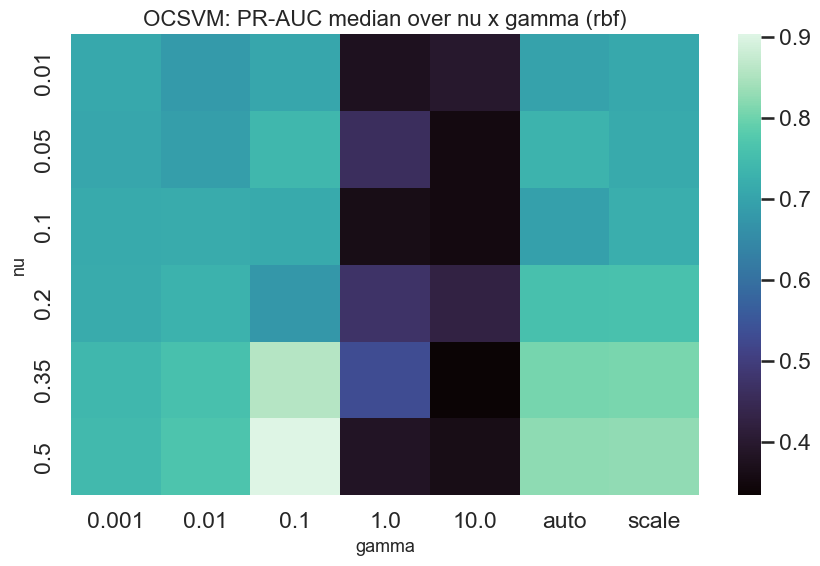

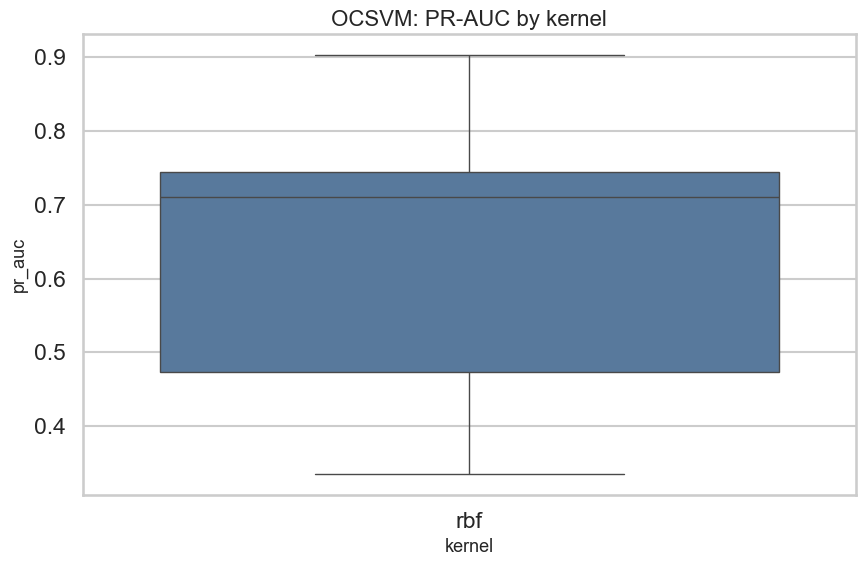

In [6]:
ocsvm = extract_param_frame("OCSVM")
if not ocsvm.empty:
    rbf = ocsvm[ocsvm["kernel"] == "rbf"].copy()
    if not rbf.empty:
        heat = rbf.pivot_table(index="nu", columns="gamma", values="pr_auc", aggfunc="median")
        fig, ax = plt.subplots(figsize=(9, 6))
        sns.heatmap(heat, cmap=HEATMAP_CMAP, ax=ax)
        ax.set_title("OCSVM: PR-AUC median over nu x gamma (rbf)")
        plt.tight_layout()
        # annotate_figure(
        #     fig, "Median PR-AUC over all OCSVM runs with kernel=rbf binned by nu and gamma."
        # )
        save_figure("deepdive_ocsvm_nu_gamma_heatmap.png")

    fig, ax = plt.subplots(figsize=(9, 6))
    sns.boxplot(data=ocsvm, x="kernel", y="pr_auc", ax=ax)
    ax.set_title("OCSVM: PR-AUC by kernel")
    plt.tight_layout()
    # annotate_figure(fig, "Distribution of PR-AUC across all OCSVM runs grouped by kernel.")
    save_figure("deepdive_ocsvm_kernel_box.png")

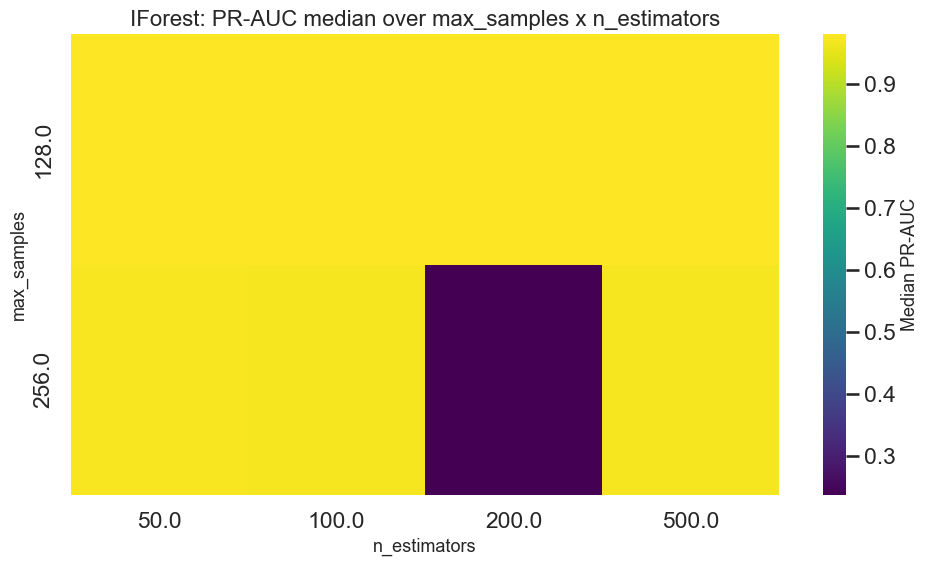

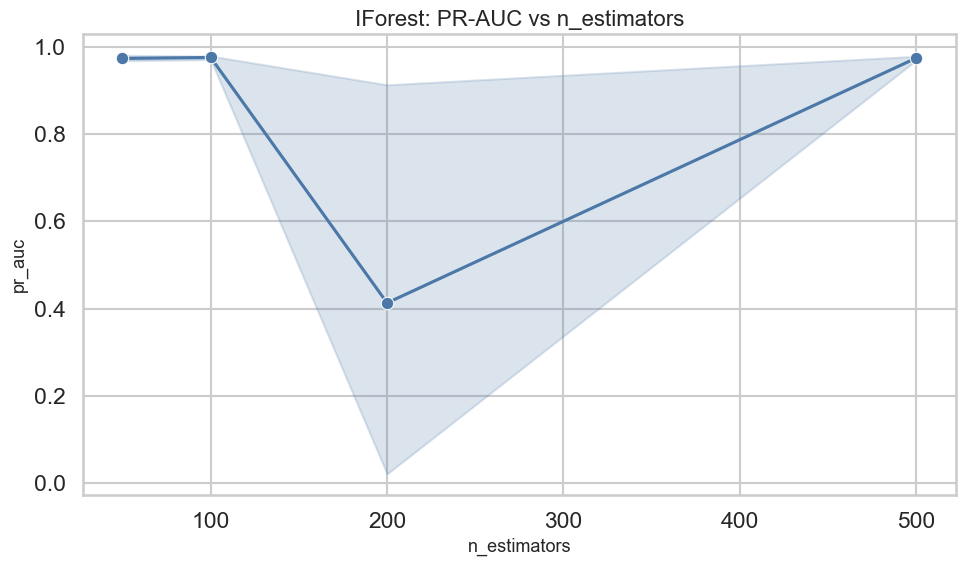

In [7]:
iforest = extract_param_frame("IForest")
if not iforest.empty:
    heat = iforest.pivot_table(
        index="max_samples", columns="n_estimators", values="pr_auc", aggfunc="median"
    )
    fig, ax = plt.subplots(figsize=(10, 6))
    observed_min = float(heat.min().min())
    observed_max = float(heat.max().max())
    sns.heatmap(
        heat,
        cmap="viridis",
        vmin=observed_min,
        vmax=observed_max,
        ax=ax,
        cbar_kws={"label": "Median PR-AUC"},
    )
    ax.set_title("IForest: PR-AUC median over max_samples x n_estimators")
    plt.tight_layout()
    # annotate_figure(fig, "Median PR-AUC across all IForest runs by max_samples and n_estimators.")
    save_figure("deepdive_iforest_samples_estimators_heatmap.png")
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.lineplot(data=iforest, x="n_estimators", y="pr_auc", marker="o", errorbar=("pi", 50), ax=ax)
    ax.set_title("IForest: PR-AUC vs n_estimators")
    plt.tight_layout()
    # annotate_figure(
    #     fig, "Line aggregates all IForest runs with percentile interval bars by n_estimators."
    # )
    save_figure("deepdive_iforest_prauc_vs_estimators.png")

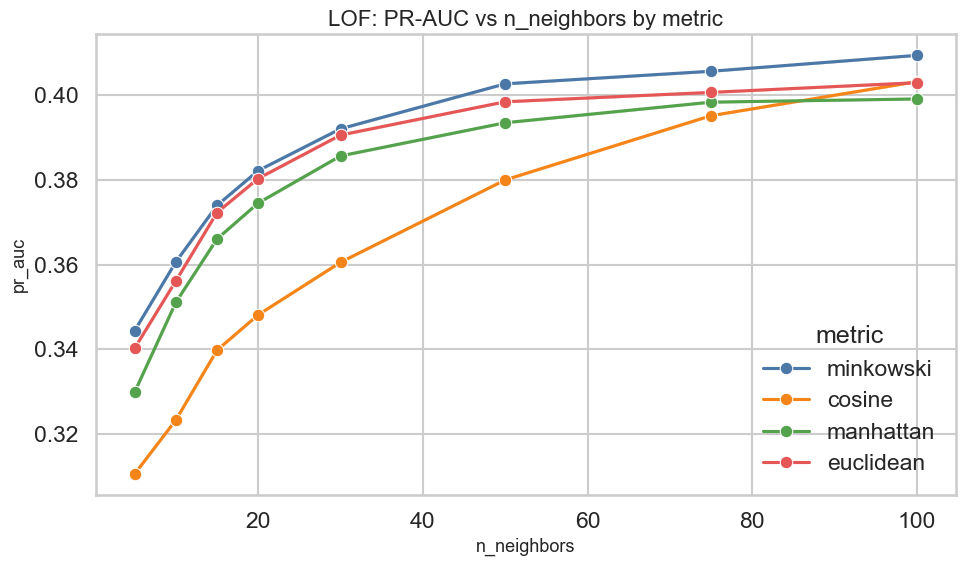

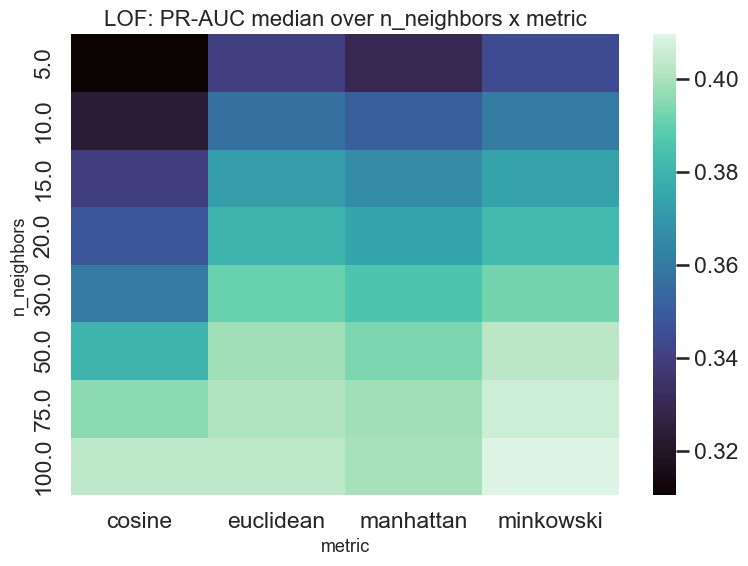

In [8]:
lof = extract_param_frame("LOF")
if not lof.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.lineplot(
        data=lof, x="n_neighbors", y="pr_auc", hue="metric", marker="o", errorbar=("pi", 50), ax=ax
    )
    ax.set_title("LOF: PR-AUC vs n_neighbors by metric")
    plt.tight_layout()
    # annotate_figure(fig, "LOF PR-AUC vs n_neighbors aggregated across runs, split by metric.")
    save_figure("deepdive_lof_neighbors_metric.png")

    heat = lof.pivot_table(index="n_neighbors", columns="metric", values="pr_auc", aggfunc="median")
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(heat, cmap=HEATMAP_CMAP, ax=ax)
    ax.set_title("LOF: PR-AUC median over n_neighbors x metric")
    plt.tight_layout()
    # annotate_figure(fig, "Median LOF PR-AUC over n_neighbors x metric grid.")
    save_figure("deepdive_lof_neighbors_metric_heatmap.png")

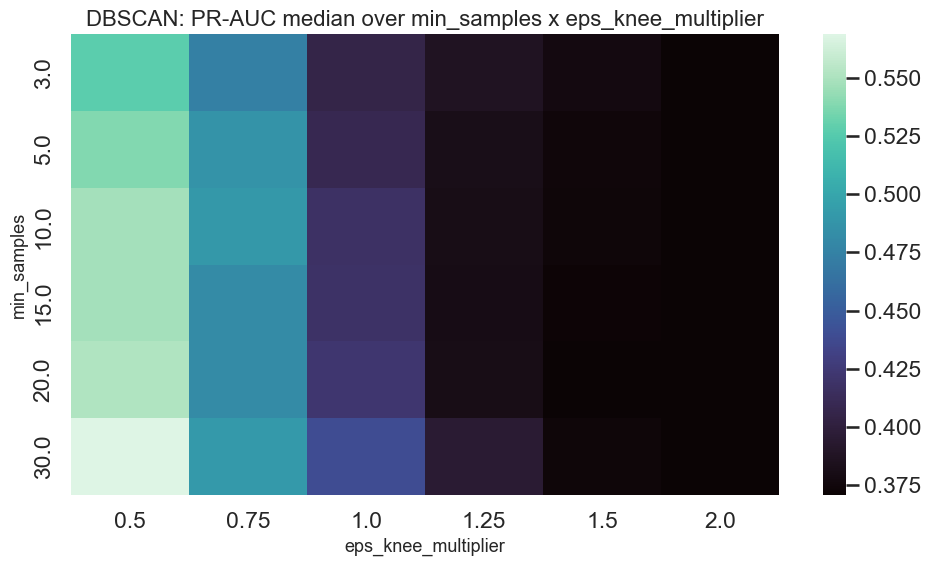

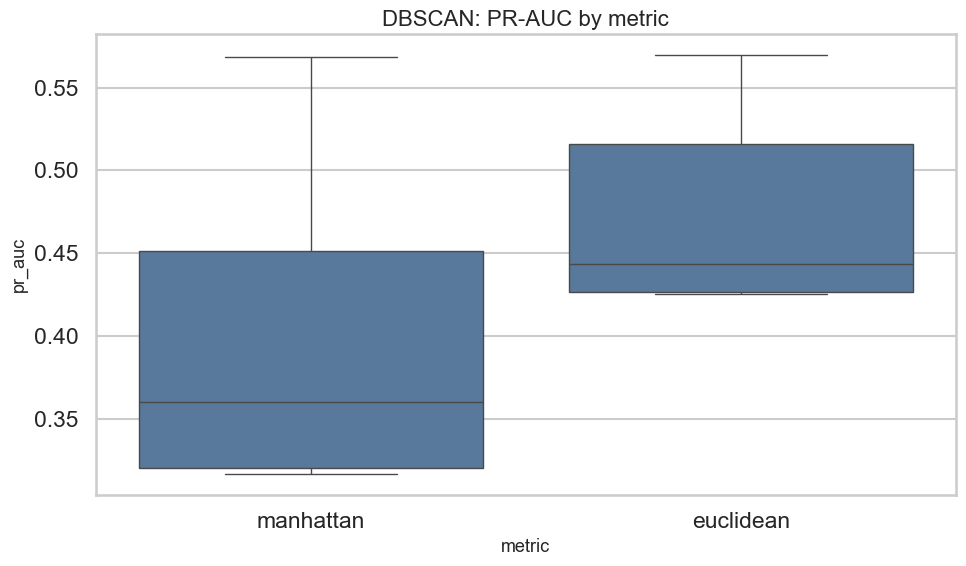

In [9]:
dbscan = extract_param_frame("DBSCAN")
if not dbscan.empty:
    heat = dbscan.pivot_table(
        index="min_samples", columns="eps_knee_multiplier", values="pr_auc", aggfunc="median"
    )
    if not heat.empty:
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.heatmap(heat, cmap=HEATMAP_CMAP, ax=ax)
        ax.set_title("DBSCAN: PR-AUC median over min_samples x eps_knee_multiplier")
        plt.tight_layout()
        # annotate_figure(fig, "Median DBSCAN PR-AUC over eps_knee_multiplier x min_samples grid.")
        save_figure("deepdive_dbscan_eps_min_samples_heatmap.png")

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(data=dbscan, x="metric", y="pr_auc", ax=ax)
    ax.set_title("DBSCAN: PR-AUC by metric")
    plt.tight_layout()
    # annotate_figure(fig, "DBSCAN PR-AUC distribution grouped by metric across all runs.")
    save_figure("deepdive_dbscan_metric_box.png")

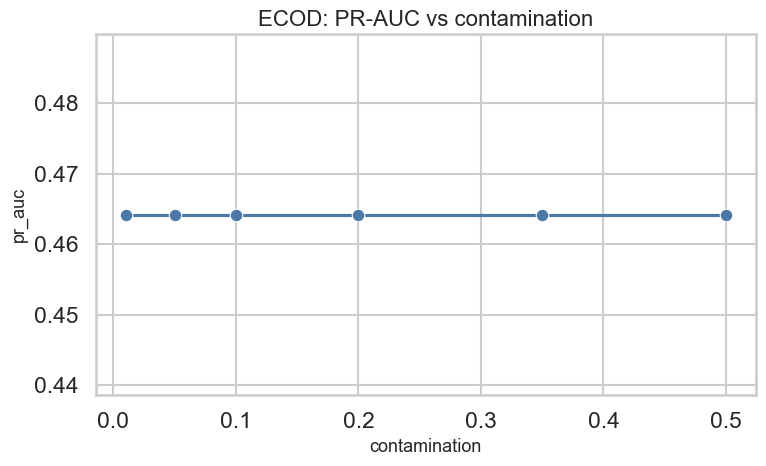

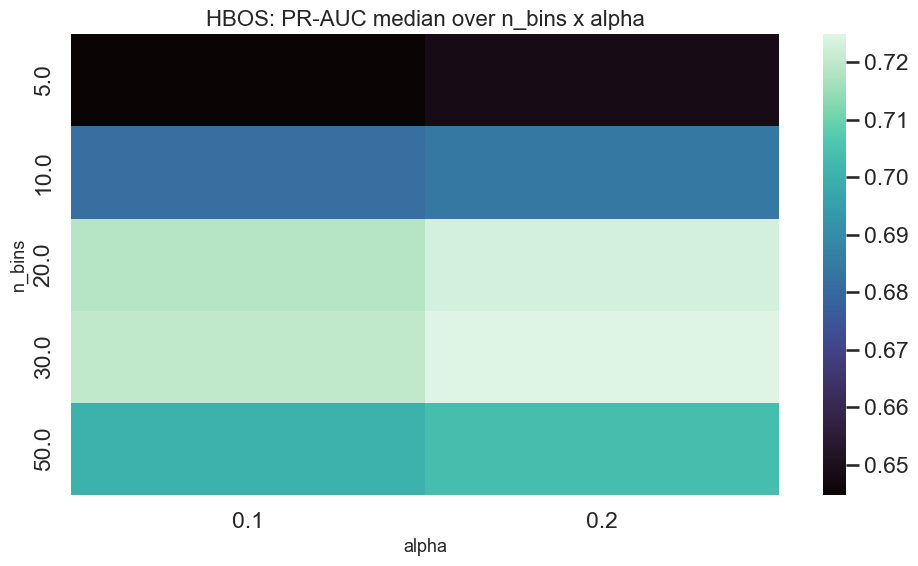

In [10]:
ecod = extract_param_frame("ECOD")
if not ecod.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.lineplot(data=ecod, x="contamination", y="pr_auc", marker="o", errorbar=("pi", 50), ax=ax)
    ax.set_title("ECOD: PR-AUC vs contamination")
    plt.tight_layout()
    # annotate_figure(fig, "ECOD PR-AUC vs contamination across all ECOD runs.")
    save_figure("deepdive_ecod_contamination_line.png")

hbos = extract_param_frame("HBOS")
if not hbos.empty:
    heat = hbos.pivot_table(index="n_bins", columns="alpha", values="pr_auc", aggfunc="median")
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(heat, cmap=HEATMAP_CMAP, ax=ax)
    ax.set_title("HBOS: PR-AUC median over n_bins x alpha")
    plt.tight_layout()
    # annotate_figure(fig, "Median HBOS PR-AUC over n_bins x alpha.")
    save_figure("deepdive_hbos_bins_alpha_heatmap.png")

## 3) Quantified Hyperparameter Importance

I train a lightweight surrogate and compute permutation importance to estimate which parameters matter most.

In [11]:
def importance_for_algorithm(algorithm: str) -> pd.DataFrame:
    sub = extract_param_frame(algorithm)
    if sub.empty:
        return pd.DataFrame(columns=["algorithm", "parameter", "importance", "r2"])

    params = [p for p in ALGO_PARAM_CANDIDATES[algorithm] if p in sub.columns]
    model_df = sub[[*params, "pr_auc"]].copy()
    model_df = pd.get_dummies(
        model_df, columns=[p for p in params if model_df[p].dtype == "object"], dummy_na=True
    )
    model_df = model_df.dropna(subset=["pr_auc"])
    if model_df.shape[0] < 40 or model_df.shape[1] < 2:
        return pd.DataFrame(columns=["algorithm", "parameter", "importance", "r2"])

    x = model_df.drop(columns=["pr_auc"]).fillna(0.0)
    y = model_df["pr_auc"].to_numpy()
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

    reg = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
    reg.fit(x_train, y_train)
    y_pred = reg.predict(x_test)
    score = float(r2_score(y_test, y_pred))

    perm = permutation_importance(reg, x_test, y_test, n_repeats=8, random_state=42, n_jobs=-1)
    imp = pd.DataFrame({"feature": x.columns, "importance": perm.importances_mean})

    # Collapse one-hot encoded features back to original param buckets.
    rows = []
    for param in params:
        prefix = f"{param}_"
        mask = imp["feature"].eq(param) | imp["feature"].str.startswith(prefix)
        if not mask.any():
            continue
        rows.append(
            {
                "algorithm": algorithm,
                "parameter": param,
                "importance": float(imp.loc[mask, "importance"].sum()),
                "r2": score,
            }
        )
    out = pd.DataFrame(rows)
    if out.empty:
        return out

    total = out["importance"].sum()
    if total > 0:
        out["importance"] = out["importance"] / total
    return out.sort_values("importance", ascending=False)


importance_tables = []
for algorithm in ALGORITHM_ORDER:
    table = importance_for_algorithm(algorithm)
    if not table.empty:
        importance_tables.append(table)

importance_all = (
    pd.concat(importance_tables, ignore_index=True) if importance_tables else pd.DataFrame()
)
importance_all.head(20)

/var/folders/44/35090ghj57v176gf4tjwsvcr0000gn/T/ipykernel_85305/686944167.py:8: FutureWarning: The behavior of Index.insert with object-dtype is deprecated, in a future version this will return an object-dtype Index instead of inferring a non-object dtype. To retain the old behavior, do `idx.insert(loc, item).infer_objects(copy=False)`
  model_df = pd.get_dummies(
/var/folders/44/35090ghj57v176gf4tjwsvcr0000gn/T/ipykernel_85305/686944167.py:8: FutureWarning: The behavior of Index.insert with object-dtype is deprecated, in a future version this will return an object-dtype Index instead of inferring a non-object dtype. To retain the old behavior, do `idx.insert(loc, item).infer_objects(copy=False)`
  model_df = pd.get_dummies(


/var/folders/44/35090ghj57v176gf4tjwsvcr0000gn/T/ipykernel_85305/686944167.py:8: FutureWarning: The behavior of Index.insert with object-dtype is deprecated, in a future version this will return an object-dtype Index instead of inferring a non-object dtype. To retain the old behavior, do `idx.insert(loc, item).infer_objects(copy=False)`
  model_df = pd.get_dummies(


/var/folders/44/35090ghj57v176gf4tjwsvcr0000gn/T/ipykernel_85305/686944167.py:8: FutureWarning: The behavior of Index.insert with object-dtype is deprecated, in a future version this will return an object-dtype Index instead of inferring a non-object dtype. To retain the old behavior, do `idx.insert(loc, item).infer_objects(copy=False)`
  model_df = pd.get_dummies(


/var/folders/44/35090ghj57v176gf4tjwsvcr0000gn/T/ipykernel_85305/686944167.py:8: FutureWarning: The behavior of Index.insert with object-dtype is deprecated, in a future version this will return an object-dtype Index instead of inferring a non-object dtype. To retain the old behavior, do `idx.insert(loc, item).infer_objects(copy=False)`
  model_df = pd.get_dummies(


/var/folders/44/35090ghj57v176gf4tjwsvcr0000gn/T/ipykernel_85305/686944167.py:8: FutureWarning: The behavior of Index.insert with object-dtype is deprecated, in a future version this will return an object-dtype Index instead of inferring a non-object dtype. To retain the old behavior, do `idx.insert(loc, item).infer_objects(copy=False)`
  model_df = pd.get_dummies(
/var/folders/44/35090ghj57v176gf4tjwsvcr0000gn/T/ipykernel_85305/686944167.py:8: FutureWarning: The behavior of Index.insert with object-dtype is deprecated, in a future version this will return an object-dtype Index instead of inferring a non-object dtype. To retain the old behavior, do `idx.insert(loc, item).infer_objects(copy=False)`
  model_df = pd.get_dummies(


,algorithm,parameter,importance,r2
0,OCSVM,gamma,0.662933,0.514081
1,OCSVM,kernel,0.306615,0.514081
2,OCSVM,nu,0.030451,0.514081
3,OCSVM,degree,0.000000,0.514081
4,OCSVM,coef0,0.000000,0.514081
5,IForest,contamination,0.997000,0.586170
6,IForest,bootstrap,0.004489,0.586170
7,IForest,max_features,0.000000,0.586170
8,IForest,max_samples,-0.000735,0.586170
9,IForest,n_estimators,-0.000755,0.586170


,algorithm,parameter,importance,r2
14,DBSCAN,eps,3.693568e-01,0.348204
15,DBSCAN,metric,2.603855e-01,0.348204
16,DBSCAN,eps_knee_multiplier,1.901630e-01,0.348204
17,DBSCAN,eps_mode,1.791939e-01,0.348204
18,DBSCAN,min_samples,9.008279e-04,0.348204
19,ECOD,contamination,1.000000e+00,0.053053
20,HBOS,alpha,7.709986e-01,0.273459
21,HBOS,n_bins,2.290014e-01,0.273459
22,HBOS,contamination,-4.635752e-16,0.273459
23,HBOS,tol,-5.408377e-16,0.273459


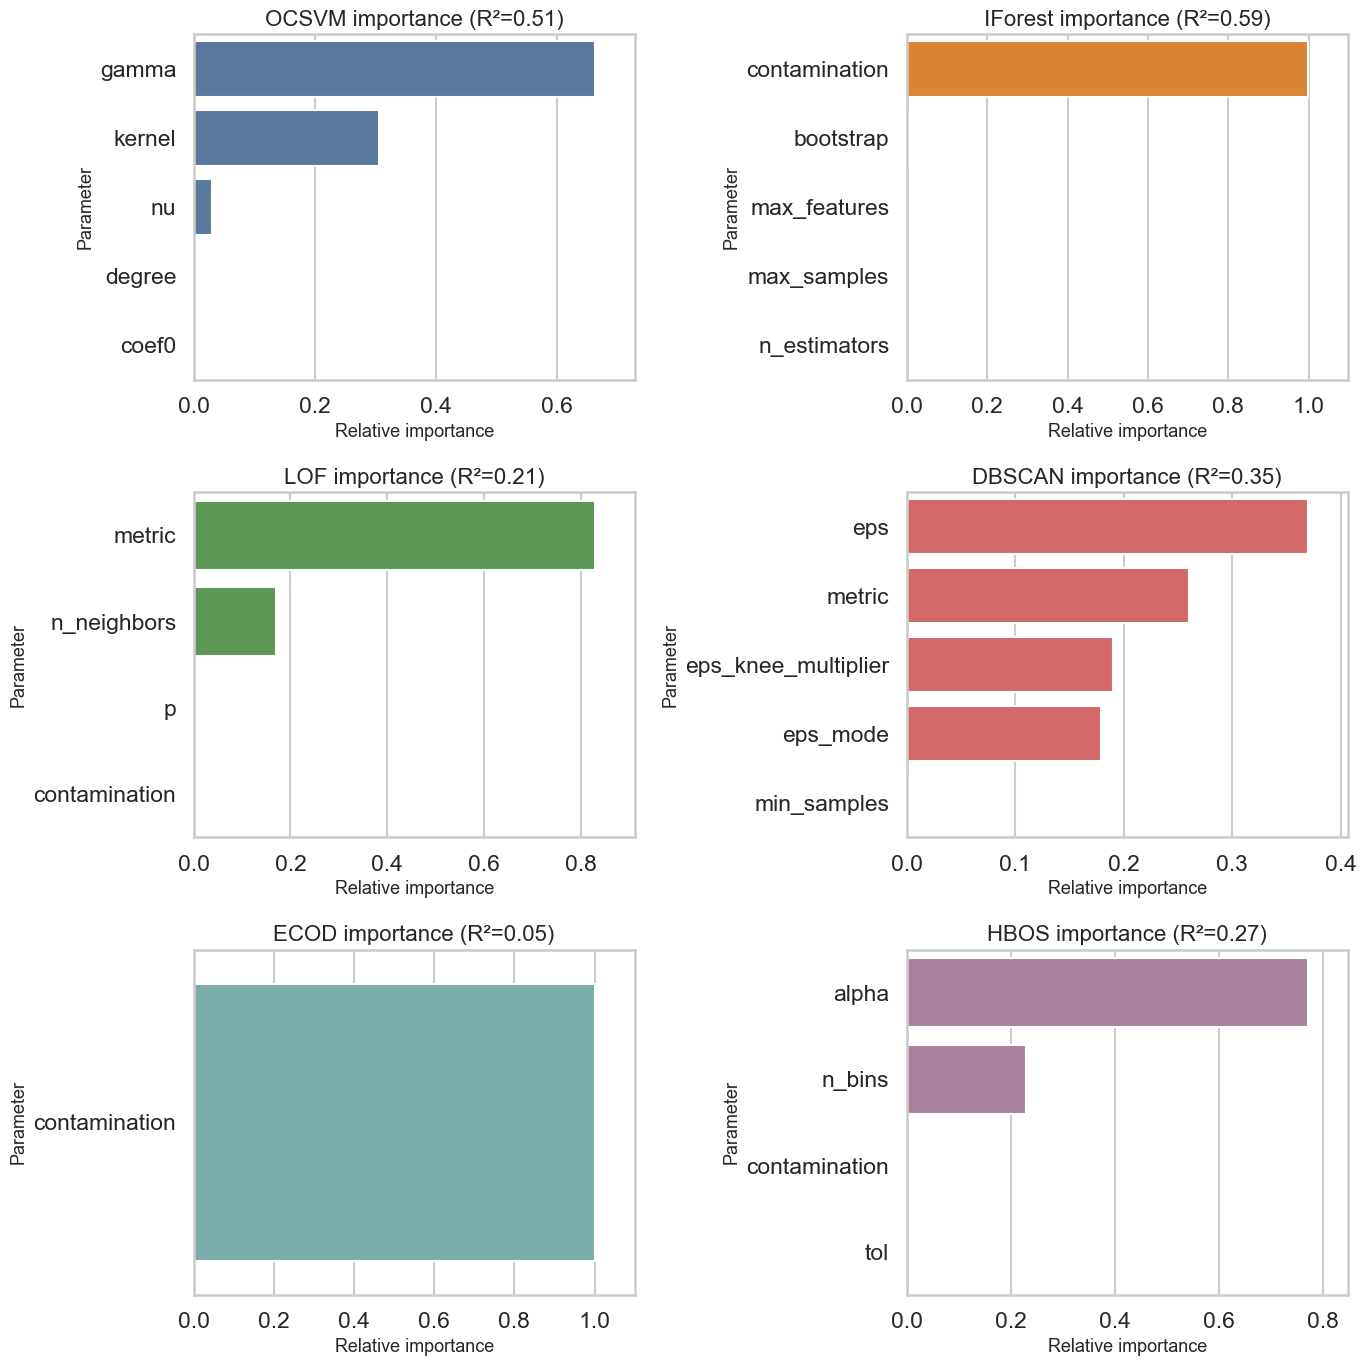

In [ ]:
if not importance_all.empty:
    fig, axes = plt.subplots(3, 2, figsize=(14, 14))
    axes_flat = axes.ravel()
    for idx, algorithm in enumerate(ALGORITHM_ORDER):
        ax = axes_flat[idx]
        sub = importance_all[importance_all["algorithm"] == algorithm]
        if sub.empty:
            ax.axis("off")
            continue
        sns.barplot(
            data=sub,
            x="importance",
            y="parameter",
            color=ALGORITHM_PALETTE.get(algorithm, "#4C78A8"),
            ax=ax,
        )
        ax.set_title(f"{algorithm} importance (R²={sub['r2'].iloc[0]:.2f})")
        ax.set_xlim(0, max(0.01, sub["importance"].max() * 1.1))
        ax.set_xlabel("Relative importance")
        ax.set_ylabel("Parameter")
    plt.tight_layout()
    # annotate_figure(
    #     fig, "Permutation importance from RF surrogate fit on run-level hyperparams per algorithm."  # noqa: E501
    # )
    save_figure("deepdive_param_importance_per_algorithm.png")

importance_all.sort_values(["algorithm", "importance"], ascending=[True, False])

## 4) Practical Hyperparameter Guidelines

Final short takeaways: which parameters are worth tuning first for each algorithm.

,algorithm,parameter,s1_mean,s1_ci_low,s1_ci_high,n_datasets
2,IForest,max_samples,0.927068,0.797490,1.104394,3
3,IForest,n_estimators,0.003496,-0.050566,0.062984,3
0,IForest,contamination,0.000000,0.000000,0.000000,3
1,IForest,max_features,-0.012651,-0.076016,0.086314,3
4,OCSVM,log10_gamma,0.414178,0.277654,0.684857,3
5,OCSVM,nu,0.251939,0.108538,0.370362,3


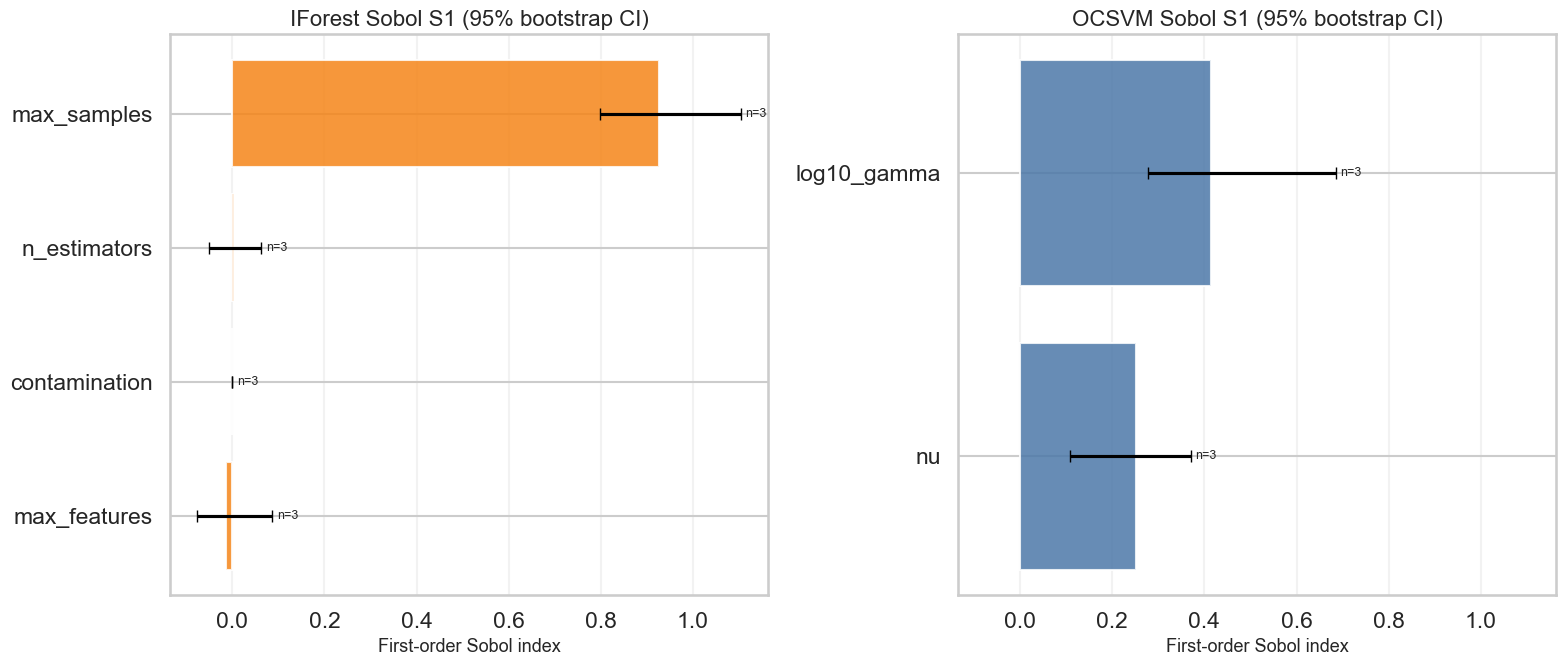

In [13]:
sobol_rows = []
for run in runs:
    tags = run.data.tags
    metrics = run.data.metrics
    algorithm = tags.get("algorithm")
    dataset = tags.get("dataset")
    if not algorithm or not dataset:
        continue
    for key, value in metrics.items():
        if not key.startswith("sobol_S1_"):
            continue
        parameter = key.replace("sobol_S1_", "", 1)
        sobol_rows.append(
            {
                "algorithm": algorithm,
                "dataset": dataset,
                "parameter": parameter,
                "s1": float(value),
            }
        )
sobol_df = pd.DataFrame(sobol_rows)
if not sobol_df.empty:
    rng = np.random.default_rng(42)
    ci_rows = []
    for (algorithm, parameter), group in sobol_df.groupby(["algorithm", "parameter"]):
        vals = group["s1"].dropna().to_numpy()
        if len(vals) == 0:
            continue
        if len(vals) == 1:
            low = high = float(vals[0])
        else:
            boots = []
            for _ in range(2000):
                sample = rng.choice(vals, size=len(vals), replace=True)
                boots.append(float(np.mean(sample)))
            low, high = np.quantile(boots, [0.025, 0.975])
        ci_rows.append(
            {
                "algorithm": algorithm,
                "parameter": parameter,
                "s1_mean": float(np.mean(vals)),
                "s1_ci_low": float(low),
                "s1_ci_high": float(high),
                "n_datasets": len(vals),
            }
        )
    sobol_ci = pd.DataFrame(ci_rows)
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True)
    for ax, algorithm in zip(axes, ["IForest", "OCSVM"], strict=False):
        sub = sobol_ci[sobol_ci["algorithm"] == algorithm].sort_values("s1_mean", ascending=True)
        if sub.empty:
            ax.axis("off")
            continue
        y = np.arange(len(sub))
        ax.barh(
            y,
            sub["s1_mean"],
            xerr=[sub["s1_mean"] - sub["s1_ci_low"], sub["s1_ci_high"] - sub["s1_mean"]],
            color=ALGORITHM_PALETTE.get(algorithm, "#4C78A8"),
            alpha=0.85,
            ecolor="black",
            capsize=4,
        )
        ax.set_yticks(y)
        ax.set_yticklabels(sub["parameter"])
        ax.set_title(f"{algorithm} Sobol S1 (95% bootstrap CI)")
        ax.set_xlabel("First-order Sobol index")
        ax.grid(axis="x", alpha=0.25)
        for yi, n in enumerate(sub["n_datasets"]):
            ax.text(sub["s1_ci_high"].iloc[yi] + 0.01, yi, f"n={n}", va="center", fontsize=9)
    plt.tight_layout()
    save_figure("deepdive_sobol_s1_with_ci.png")
sobol_ci.sort_values(
    ["algorithm", "s1_mean"], ascending=[True, False]
) if not sobol_df.empty else sobol_df

In [14]:
guidelines = (
    importance_all.sort_values(["algorithm", "importance"], ascending=[True, False])
    .groupby("algorithm")
    .head(2)
    .copy()
)
if not guidelines.empty:
    guidelines["note"] = guidelines["parameter"].astype(str) + " shows strongest sensitivity."

guidelines[["algorithm", "parameter", "importance", "r2", "note"]]

,algorithm,parameter,importance,r2,note
14,DBSCAN,eps,0.369357,0.348204,eps shows strongest sensitivity.
15,DBSCAN,metric,0.260386,0.348204,metric shows strongest sensitivity.
19,ECOD,contamination,1.000000,0.053053,contamination shows strongest sensitivity.
20,HBOS,alpha,0.770999,0.273459,alpha shows strongest sensitivity.
21,HBOS,n_bins,0.229001,0.273459,n_bins shows strongest sensitivity.
5,IForest,contamination,0.997000,0.586170,contamination shows strongest sensitivity.
6,IForest,bootstrap,0.004489,0.586170,bootstrap shows strongest sensitivity.
10,LOF,metric,0.828993,0.212973,metric shows strongest sensitivity.
11,LOF,n_neighbors,0.170966,0.212973,n_neighbors shows strongest sensitivity.
0,OCSVM,gamma,0.662933,0.514081,gamma shows strongest sensitivity.
